# Сергушов Павел ПМ22-4

# DeepWalk. Node2vec.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Случайные блуждания на графах"
* Документация:
    * https://radimrehurek.com/gensim/models/word2vec.html
    * https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
    * https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
    * http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
    
* Дополнительные источники:
    * https://memgraph.com/blog/how-node2vec-works
    * https://github.com/eliorc/node2vec

## Вопросы для совместного обсуждения

1\. Обсудите принцип работы алгоритмов DeepWalk и Node2vec и рассмотрите примеры обучения модели word2vec при помощи пакета `gensim`.

## Задачи для самостоятельного решения

In [1]:
import networkx as nx
import random
import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings


<p class="task" id="1"></p>

1\. Напишите функцию `generate_walk`, которая принимает на вход граф `G`, начальный узел `node` и генерирует случайное блуждание длины `walk_len`, начинающееся с этого узла. Сгенерируйте реализации 1000 случайных блужданий длины 3 с началом в случайно выбранных узлах для карате клуба. 

Используя полученные последовательности узлов, обучите модель Word2Vec из пакета `gensim` со следующими гиперпараметрами: размерность эмбеддингов 32, ширина контекстного окна 3.

Получите эмбеддинги узлов и уменьшите их размерность до 2 при помощи алгоритмов PCA или t-SNE. Визуализируйте граф, используя эмбеддинги размерности 2 в качестве координат узлов. Раскрасьте узлы в цвет соответствующего им клуба.

- [ ] Проверено на семинаре

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
def generate_walk(graph, start_node, walk_length):
    """Создает один путь (блуждание) по графу."""
    walk = [start_node] # Начинаем путь с заданного узла
    current_node = start_node
    for _ in range(walk_length - 1): # Делаем шаги (длина пути - 1)
        neighbors = list(graph.neighbors(current_node)) # Находим соседей текущего узла
        if not neighbors:
            break
        next_node = random.choice(neighbors) 
        walk.append(next_node) 
        current_node = next_node 
    return [str(node) for node in walk]

In [ ]:
G = nx.karate_club_graph() 
all_nodes = list(G.nodes())

In [ ]:
num_walks = 1000 
walk_len = 3 

In [6]:
print(f"Генерируем {num_walks} случайных блужданий длиной {walk_len}...")
all_walks = [] # Список, где будем хранить все пути
for _ in range(num_walks):
    random_start_node = random.choice(all_nodes) # Выбираем случайный узел для старта
    one_walk = generate_walk(G, random_start_node, walk_len) # Генерируем один путь
    all_walks.append(one_walk) # Добавляем его в общий список


print(f"Готово. Сгенерировано {len(all_walks)} блужданий.")
print("Пример блуждания:", all_walks[0]) 

Генерируем 1000 случайных блужданий длиной 3...
Готово. Сгенерировано 1000 блужданий.
Пример блуждания: ['9', '33', '8']


In [7]:
print("Обучаем модель Word2Vec...")
model = Word2Vec(
    sentences=all_walks,  # Наши сгенерированные пути
    vector_size=32,       # Размер вектора для каждого узла (эмбеддинга)
    window=3,             # Сколько соседей слева/справа учитывать при обучении
    min_count=1,          # Учитывать даже те узлы, что редко встречались
    sg=1                  # Используем алгоритм Skip-Gram (обычно лучше для графов)
)
print("Модель обучена.")

Обучаем модель Word2Vec...
Модель обучена.


In [8]:
# Получаем векторы (эмбеддинги) для всех узлов графа
node_embeddings = []
node_ids_in_order = [str(n) for n in G.nodes()] # Узлы графа как строки, в нужном порядке

for node_id in node_ids_in_order:
    node_embeddings.append(model.wv[node_id]) # Берем вектор для каждого узла из модели

In [ ]:
node_embeddings = np.array(node_embeddings) 
print(f"Получены эмбеддинги. Размер матрицы: {node_embeddings.shape}") 

Получены эмбеддинги. Размер матрицы: (34, 32)


In [ ]:
"Уменьшаем размерность эмбеддингов до 2"

reducer = PCA(n_components=2, random_state=42)

Уменьшаем размерность эмбеддингов до 2...


In [11]:
embeddings_2d = reducer.fit_transform(node_embeddings)
print(f"Размерность уменьшена. Новая форма: {embeddings_2d.shape}")

Размерность уменьшена. Новая форма: (34, 2)


In [12]:
positions = {}
for i, node in enumerate(G.nodes()):
    positions[node] = embeddings_2d[i]

# Определяем цвета узлов в зависимости от клуба ('Mr. Hi' или 'Officer')
colors = []
for node in G.nodes():
    club = G.nodes[node]['club'] # Получаем имя клуба для узла
    if club == 'Mr. Hi':
        colors.append('lightblue') # Синий для клуба Mr. Hi
    else:
        colors.append('lightcoral') # Красный для клуба Officer


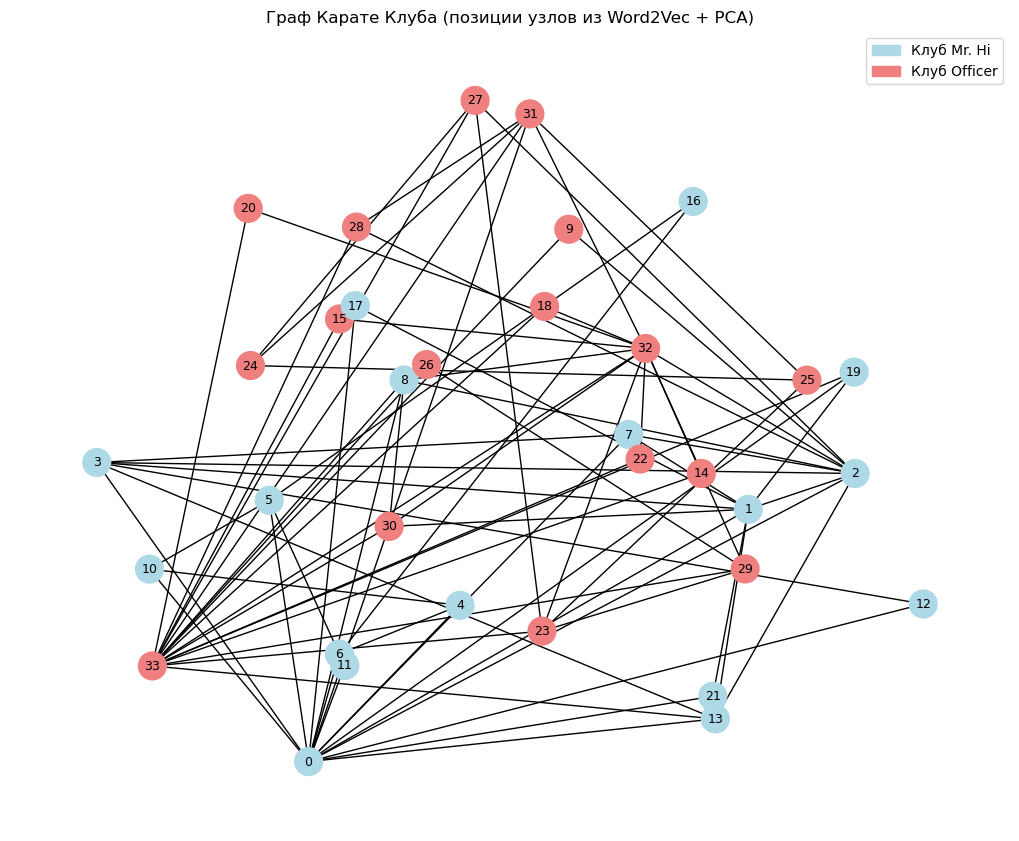

In [ ]:
# Рисуем граф
plt.figure(figsize=(10, 8)) # Размер картинки
nx.draw(
    G,
    pos=positions,      # Используем наши 2D-координаты
    node_color=colors,  # Раскрашиваем узлы по клубам
    with_labels=True,   # Показать номера узлов
    node_size=400,      # Размер узлов
    font_size=9         # Размер шрифта номеров
)


import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='lightblue', label='Клуб Mr. Hi')
red_patch = mpatches.Patch(color='lightcoral', label='Клуб Officer')
plt.legend(handles=[blue_patch, red_patch])

plt.title("Граф Карате Клуба (позиции узлов из Word2Vec + PCA)")
plt.show() # Показать график

<p class="task" id="2"></p>

2\. Используя нейронную сеть (можно воспользоваться реализацией из `sklearn` или `torch`) с одним скрытым слоем на 16 нейронов, решите задачу классификации узлов графа. В качестве признаков используйте эмбеддинги узлов, полученные в предыдущей задаче (до уменьшения размерности), в качестве меток - названия клубов узлов. Выведите на экран accuracy полученной модели.

- [ ] Проверено на семинаре

In [20]:
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split 
from sklearn.neural_network import MLPClassifier     
from sklearn.preprocessing import LabelEncoder       
from sklearn.metrics import accuracy_score 

In [21]:
node_ids_in_order = list(G.nodes())
node_ids_str = [str(n) for n in node_ids_in_order]
X = model.wv[node_ids_str]

In [22]:
print(f"Размер матрицы признаков (эмбеддингов): {X.shape}")

Размер матрицы признаков (эмбеддингов): (34, 32)


In [23]:
# Получаем метки (названия клубов) для каждого узла
labels = [G.nodes[node]['club'] for node in node_ids_in_order]

In [24]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels) # Это наши целевые переменные

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} узлов")
print(f"Размер тестовой выборки: {X_test.shape[0]} узлов")

Размер обучающей выборки: 23 узлов
Размер тестовой выборки: 11 узлов


In [ ]:
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True, 
    n_iter_no_change=10
)

In [ ]:
mlp_classifier.fit(X_train, y_train)

print("Нейронная сеть обучена.")

Нейронная сеть обучена.


In [30]:
y_pred = mlp_classifier.predict(X_test)

# Считаем точность (accuracy) - долю правильных предсказаний
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность (Accuracy) нейронной сети на тестовой выборке: {accuracy:.4f}")

Точность (Accuracy) нейронной сети на тестовой выборке: 0.4545


<p class="task" id="3"></p>

3\. Напишите функцию `generate_biased_walk`, которая принимает на вход граф `G`, начальный узел `node` и генерирует смещенное случайное блуждание длины `walk_len`, начинающееся с этого узла. 

![](https://i.imgur.com/CtnVJFJ.png)

Сгенерируйте реализации 1000 случайных блужданий длины 3 с началом в случайно выбранных узлах. 

- [ ] Проверено на семинаре

In [ ]:
def generate_biased_walk(G, node, walk_len, p, q):
    pass

<p class="task" id="4"></p>

4\. Сгенерируйте реализации 1000 смещенных случайных блужданий длины 5 с началом в случайно выбранных узлах с параметрами `p=1` и `q=2`. 

Используя полученные последовательности узлов, обучите модель Word2Vec из пакета `gensim` со следующими гиперпараметрами: размерность эмбеддингов 32, ширина контекстного окна 3.

Получите эмбеддинги узлов и уменьшите их размерность до 2 при помощи алгоритмов PCA или t-SNE. Визуализируйте граф, используя эмбеддинги размерности 2 в качестве координат узлов. Раскрасьте узлы в цвет соответствующего им клуба.

- [ ] Проверено на семинаре

<p class="task" id="5"></p>

5\. Используя  [готовую реализацию node2vec](https://github.com/eliorc/node2vec), обучите модель с гиперпараметрами, аналогичными предыдущей задачи. Получите эмбеддинги узлов и уменьшите их размерность до 2 при помощи алгоритмов PCA или t-SNE. Визуализируйте граф, используя эмбеддинги размерности 2 в качестве координат узлов. Раскрасьте узлы в цвет соответствующего им клуба.

- [ ] Проверено на семинаре

In [ ]:
!pip install node2vec